### Métodos Numéricos Computacionales
#### Prácticas computacionales de "Métodos numéricos en álgebra lineal"

Instrucciones para los Ejercicios

1. **Trabajo en Grupo:**
   - Los ejercicios deben ser resueltos y entregados en grupo.
   - La cantidad de integrantes por grupo será definida el día de la actividad, así como la fecha límite para la entrega.

2. **Uso de Google Colab y Compartir:**
   - Este notebook debe ser copiado al GitHub o Google Drive de alguno de los integrantes del grupo.
   - El grupo será responsable de programar las soluciones, realizar las pruebas y enviar el trabajo final al profesor.

3. **Implementación de los Ejercicios:**
   - Cada ejercicio debe ser implementado de manera que cumpla con los objetivos específicos descritos en cada problema.
   - El código debe devolver claramente la información calculada de acuerdo a lo solicitado.

4. **Calidad del Código:**
   - El código debe ejecutarse sin errores.
   - Es obligatorio incluir **comentarios explicativos** para describir las ideas y conceptos implícitos en el código, facilitando la comprensión de su lógica.

5. **Envío del Trabajo:**
   - Una vez completado, el notebook debe ser enviado a través de Moodle.
   - En caso de dudas, pueden contactarme por correo electrónico a **marcelo.danesi@utec.edu.uy**.

6. **Orientaciones Adicionales:**
   - Asegúrense de que todas las celdas de código hayan sido ejecutadas antes de enviar.
   - Incluyan el nombre completo y correo electrónico de todos los integrantes al inicio del notebook.
   - Si utilizan referencias externas, menciónenlas de forma adecuada.

¡Buena suerte y aprovechen la práctica para consolidar los conceptos de métodos numéricos!

En esta práctica trabajaremos con métodos numéricos para resolver problemas comunes de **álgebra lineal aplicada**, en particular:

- Cálculo aproximado de valores propios y vectores propios
- Resolución de sistemas lineales por métodos iterativos
- Aplicación del método de Newton-Raphson multivariable
- Aproximación matricial mediante descomposición en valores singulares

Estos métodos se utilizan frecuentemente en aplicaciones de ingeniería, simulación, machine learning y optimización.


#### **Cálculo de valores propios: Método de la potencia**

El **método de la potencia** es una técnica numérica simple pero eficaz para obtener el **autovalor dominante** (es decir, el de mayor valor absoluto) de una matriz cuadrada $A$. Además, proporciona una buena aproximación del autovector asociado.

Este método es especialmente útil cuando la matriz es grande y dispersa, o cuando solo se necesita el autovalor dominante.

**Fundamento del método**  
Dada una matriz cuadrada $A \in \mathbb{R}^{n \times n}$ y un vector inicial $x^{(0)}$, iteramos:

$$x^{(k+1)} = \frac{A x^{(k)}}{\|A x^{(k)}\|}.$$

Y aproximamos el autovalor correspondiente con:

$$\lambda^{(k)} = \left(x^{(k)}\right)^T \cdot A \cdot x^{(k)}. $$

La convergencia es rápida si $A$ tiene un autovalor dominante claro.


##### **Ejemplo: Implementación del Método de la potencia**

**Descripción del problema:**  
Sea la matriz:
$$A = \begin{bmatrix}
2 & 1 & 1 & 1 & 1 & 1 \\
1 & 1 & 1 & 1 & 1 & 1 \\
4 & 1 & 1 & 1 & 1 & 1 \\
4 & 1 & 1 & 1 & 1 & 1 \\
4 & 1 & 1 & 1 & 1 & 1 \\
2 & 3 & 1 & 1 & 1 & 1
\end{bmatrix}.$$

Queremos estimar su mayor autovalor y el autovector asociado usando el método de la potencia, comenzando con el vector inicial $x^{(0)} = \begin{bmatrix} 1 \\ 1 \\ 1 \\ 1 \\ 1 \\ 1 \end{bmatrix}$ y calculando $\lambda^{(0)}, \ldots, \lambda^{(10)}$.

**Objetivos:**  
- Implementar el método de la potencia.
- Estimar el mayor autovalor de la matriz.
- Graficar la evolución del autovalor en cada paso.
- Adicional: Calcular el error de la aproximación
$$ E = \| A\cdot x^{(10)} - \lambda^{(10)} x^{(10)} \|.$$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definimos la matriz A
A = np.array([[2, 1, 1, 1, 1, 1],
              [1, 1, 1, 1, 1, 1],
              [4, 1, 1, 1, 1, 1],
              [4, 1, 1, 1, 1, 1],
              [4, 1, 1, 1, 1, 1],
              [2, 3, 1, 1, 1, 1]])

# Vector inicial (puede ser cualquier vector no nulo)
x = np.array([1, 1, 1, 1, 1, 1], dtype=float)

# Lista para guardar las estimaciones de los autovectores
autovectores = []
# Lista para guardar las estimaciones de los autovalores
autovalores = []

# Aquí está el cálculo de \lambda^{(0)}
lambda_aprox = x.T @ A @ x
autovectores.append(x)
autovalores.append(lambda_aprox)

# Bucle para \lambda^{(1)} al \lambda^{(10)}
for i in range(10):                   # o range(1,11), i no importa
    Ax = A @ x                        # Multiplicamos A por el vector actual
    x = Ax / np.linalg.norm(Ax)       # Normalizamos el vector
    lambda_aprox = x.T @ A @ x        # Estimación del autovalor
    autovectores.append(x)
    autovalores.append(lambda_aprox)

# Mostramos los resultados
print("Autovalor dominante aproximado:", autovalores[-1])
print("Autovector asociado (normalizado):", x)

# Graficamos la evolución del autovalor
plt.plot(autovalores, marker='o')
plt.title("Convergencia del método de la potencia")
plt.xlabel("Iteración")
plt.ylabel("Autovalor estimado")
plt.grid()
plt.show()

# Adicional: Calculamos el error del autovector y autovalor aproximados
# Error = A @ x - lambda * x
error = A @ x - lambda_aprox * x

# Mostramos el vector de error y su norma
print("Vector de error (A·x - λ·x):", error)
print("Norma del error:", np.linalg.norm(error))

##### **Ejercicio 1: Primeros pasos con el método de la potencia**

**Descripción del problema:**  
Considere la matriz
$$
A = \begin{bmatrix}
4 & 1 \\
2 & 3
\end{bmatrix}.
$$

Use el método de la potencia para estimar su mayor autovalor y el autovector asociado. Utilice el vector inicial $x^{(0)} = \begin{bmatrix} 1 \\ 1 \end{bmatrix}$ y realice 10 iteraciones.

**Objetivos:**
- Calcular las sucesivas estimaciones de $\lambda^{(k)}$.
- Graficar la convergencia del autovalor.
- Mostrar el vector de error $E = \|Ax^{(k)} - \lambda^{(k)}x^{(k)}\|$.

##### **Ejercicio 2: Aplicación a una matriz 3x3**

**Descripción del problema:**  
Use el método de la potencia para estimar el autovalor dominante de la matriz
$$
A = \begin{bmatrix}
2 & -1 & 0 \\
-1 & 2 & -1 \\
0 & -1 & 2
\end{bmatrix}.
$$

con vector inicial $x^{(0)} = \begin{bmatrix} 1 \\ 1 \\ 1 \end{bmatrix}$, usando 15 iteraciones.

**Objetivos:**
- Imprimir las estimaciones $\lambda^{(k)}$ en cada paso.
- Evaluar la norma del error $E_k = \|Ax^{(k)} - \lambda^{(k)}x^{(k)}\|$ en cada paso.
- Comentar si el método converge claramente o no.


##### **Ejercicio 3: Comparación con valores reales**

**Descripción del problema:**  
Dada la matriz
$$
A = \begin{bmatrix}
6 & 2 & 1 \\
2 & 3 & 1 \\
1 & 1 & 1
\end{bmatrix},
$$

utilice el método de la potencia para estimar el autovalor dominante. Compare su resultado con los autovalores reales obtenidos por `np.linalg.eig`.

**Objetivos:**
- Realizar 20 iteraciones del método.
- Comparar el resultado con la función `eig` de NumPy.
- Mostrar el error relativo entre la estimación numérica y el valor exacto.

##### **Ejercicio 4: Evaluación de convergencia con múltiples vectores iniciales**

**Descripción del problema:**  
Use la misma matriz del ejercicio anterior. Aplique el método de la potencia con distintos vectores iniciales:
- $x^{(0)} = [1, 1, 1]^T$
- $x^{(0)} = [1, 0, 0]^T$
- $x^{(0)} = [0, 1, 0]^T$

**Objetivos:**
- Verificar si la convergencia depende del vector inicial.
- Graficar la evolución de $\lambda^{(k)}$ para cada caso.
- Comentar los resultados obtenidos.


#### **Cálculo de valores propios: Método de Jacobi**

El **método de Jacobi** es un algoritmo iterativo para calcular **todos los autovalores y autovectores reales** de una **matriz simétrica real**. A diferencia del método de la potencia, que encuentra solo el autovalor dominante, Jacobi permite obtener la **diagonalización completa** de la matriz.

Este método consiste en aplicar sucesivas rotaciones ortogonales para **anular los elementos fuera de la diagonal**, transformando progresivamente la matriz en una forma diagonal. Las rotaciones se hacen mediante **matrices de rotación de Givens**, que solo afectan dos filas y columnas a la vez.

Dado que las matrices de rotación son ortogonales, se mantiene la semejanza con la matriz original, por lo que los autovalores permanecen invariantes.

El algoritmo converge cuando todos los elementos fuera de la diagonal son suficientemente pequeños (menores que una tolerancia dada).

##### **Ejemplo: Implementación del Método de Jacobi**

**Descripción del problema:**  
Sea la matriz simétrica
$$
A = \begin{bmatrix}
4 & -2 & 2 \\
-2 & 3 & -1 \\
2 & -1 & 5
\end{bmatrix}.
$$

Queremos encontrar todos sus autovalores y autovectores utilizando el método de Jacobi, con tolerancia $\varepsilon = 10^{-8}$.

**Objetivos:**
- Implementar el método de Jacobi para matrices simétricas.
- Diagonalizar la matriz mediante rotaciones sucesivas.
- Obtener los autovalores en la diagonal y los autovectores como columnas de la matriz de rotación acumulada.


In [ ]:
import numpy as np

# Función para encontrar el índice del mayor elemento fuera de la diagonal
def indice_max_offdiag(A):
    n = A.shape[0]
    max_val = 0
    p, q = 0, 1
    for i in range(n):
        for j in range(i + 1, n):
            if abs(A[i, j]) > max_val:
                max_val = abs(A[i, j])
                p, q = i, j
    return p, q, max_val

# Implementación del método de Jacobi
def metodo_jacobi(A, tol=1e-8, max_iter=100):
    n = A.shape[0]
    A = A.copy()
    V = np.eye(n)  # Matriz de autovectores

    for it in range(max_iter):
        p, q, max_offdiag = indice_max_offdiag(A)
        if max_offdiag < tol:
            break

        # Cálculo de los ángulos de rotación
        if A[p, p] == A[q, q]:
            theta = np.pi / 4
        else:
            tau = (A[q, q] - A[p, p]) / (2 * A[p, q])
            t = np.sign(tau) / (abs(tau) + np.sqrt(1 + tau ** 2))
            theta = np.arctan(t)

        c = np.cos(theta)
        s = np.sin(theta)

        # Construcción de la matriz de rotación
        J = np.eye(n)
        J[p, p] = c
        J[q, q] = c
        J[p, q] = s
        J[q, p] = -s

        # Actualización de la matriz A y acumulación de autovectores
        A = J.T @ A @ J
        V = V @ J

    autovalores = np.diag(A)
    return autovalores, V

# Prueba con la matriz del ejemplo
A = np.array([[4, -2, 2],
              [-2, 3, -1],
              [2, -1, 5]], dtype=float)

autovalores, autovectores = metodo_jacobi(A)

print("Autovalores aproximados:")
print(autovalores)

print("Matriz de autovectores (columnas):")
print(autovectores)

# Verificación: A·v ≈ λ·v
for i in range(3):
    print("\nVerificación para el autovalor", autovalores[i])
    print("A·v =", A @ autovectores[:, i])
    print("λ·v =", autovalores[i] * autovectores[:, i])

Autovalores aproximados:
[7.50466435 1.35997653 3.13535911]
Matriz de autovectores (columnas):
[[ 0.61886638  0.67494789 -0.4018081 ]
 [-0.42185901  0.71709346  0.55480803]
 [ 0.66260047 -0.17384567  0.72851788]]

Verificación para el autovalor 7.5046643535880495
A·v = [ 4.64438448 -3.16591025  4.97259411]
λ·v = [ 4.64438448 -3.16591025  4.97259411]

Verificación para el autovalor 1.359976533107355
A·v = [ 0.91791329  0.97523028 -0.23642603]
λ·v = [ 0.91791329  0.97523028 -0.23642603]

Verificación para el autovalor 3.135359113304597
A·v = [-1.25981269  1.7395224   2.28416518]
λ·v = [-1.25981269  1.7395224   2.28416518]


##### **Ejercicio 1: Aplicación básica del método de Jacobi**

**Descripción del problema:**  
Considere la siguiente matriz simétrica:
$$
A = \begin{bmatrix}
2 & 1 & 0 \\
1 & 3 & 1 \\
0 & 1 & 2
\end{bmatrix}.
$$

**Objetivos:**
- Implementar el método de Jacobi paso a paso.
- Calcular los autovalores y autovectores.
- Verificar la relación $A \cdot v = \lambda \cdot v$ para cada autovector.

In [2]:
import numpy as np

# Función para encontrar el índice del mayor elemento fuera de la diagonal
def indice_max_offdiag(A):
    n = A.shape[0]
    max_val = 0
    p, q = 0, 1
    for i in range(n):
        for j in range(i + 1, n):
            if abs(A[i, j]) > max_val:
                max_val = abs(A[i, j])
                p, q = i, j
    return p, q, max_val

# Implementación del método de Jacobi
def metodo_jacobi(A, tol=1e-8, max_iter=100):
    n = A.shape[0]
    A = A.copy()
    V = np.eye(n)  # Matriz de autovectores

    for it in range(max_iter):
        p, q, max_offdiag = indice_max_offdiag(A)
        if max_offdiag < tol:
            break

        # Cálculo de los ángulos de rotación
        if A[p, p] == A[q, q]:
            theta = np.pi / 4
        else:
            tau = (A[q, q] - A[p, p]) / (2 * A[p, q])
            t = np.sign(tau) / (abs(tau) + np.sqrt(1 + tau ** 2))
            theta = np.arctan(t)

        c = np.cos(theta)
        s = np.sin(theta)

        # Construcción de la matriz de rotación
        J = np.eye(n)
        J[p, p] = c
        J[q, q] = c
        J[p, q] = s
        J[q, p] = -s

        # Actualización de la matriz A y acumulación de autovectores
        A = J.T @ A @ J
        V = V @ J

    autovalores = np.diag(A)
    return autovalores, V

# Prueba con la matriz del ejemplo
A = np.array([[ 2, 1, 0 ],
              [ 1, 3, 1],
              [ 0, 1, 2]], dtype=float)

autovalores, autovectores = metodo_jacobi(A)

print("Autovalores aproximados:")
print(autovalores)

print("Matriz de autovectores (columnas):")
print(autovectores)

# Verificación: A·v ≈ λ·v
for i in range(3):
    print("\nVerificación para el autovalor", autovalores[i])
    print("A·v =", A @ autovectores[:, i])
    print("λ·v =", autovalores[i] * autovectores[:, i])

Autovalores aproximados:
[1. 4. 2.]
Matriz de autovectores (columnas):
[[ 5.77350270e-01  4.08248290e-01 -7.07106781e-01]
 [-5.77350269e-01  8.16496581e-01 -2.59318893e-10]
 [ 5.77350269e-01  4.08248290e-01  7.07106781e-01]]

Verificación para el autovalor 1.0000000000000002
A·v = [ 0.57735027 -0.57735027  0.57735027]
λ·v = [ 0.57735027 -0.57735027  0.57735027]

Verificación para el autovalor 3.9999999999999996
A·v = [1.63299316 3.26598632 1.63299316]
λ·v = [1.63299316 3.26598632 1.63299316]

Verificación para el autovalor 1.9999999999999996
A·v = [-1.41421356e+00 -2.59318678e-10  1.41421356e+00]
λ·v = [-1.41421356e+00 -5.18637786e-10  1.41421356e+00]


##### **Ejercicio 2: Comparación con valores exactos**

**Descripción del problema:**  
Sea la matriz simétrica:
$$
A = \begin{bmatrix}
6 & 2 & 1 \\
2 & 3 & 1 \\
1 & 1 & 1
\end{bmatrix}.
$$

**Objetivos:**
- Aplicar el método de Jacobi para calcular todos los autovalores.
- Comparar con los valores exactos obtenidos por `numpy.linalg.eig`.
- Calcular el error absoluto entre los resultados.


In [9]:
import numpy as np

# Función para encontrar el índice del mayor elemento fuera de la diagonal
def indice_max_offdiag(A):
    n = A.shape[0]
    max_val = 0
    p, q = 0, 1
    for i in range(n):
        for j in range(i + 1, n):
            if abs(A[i, j]) > max_val:
                max_val = abs(A[i, j])
                p, q = i, j
    return p, q, max_val

# Implementación del método de Jacobi
def metodo_jacobi(A, tol=1e-8, max_iter=100):
    n = A.shape[0]
    A = A.copy()
    V = np.eye(n)  # Matriz de autovectores

    for it in range(max_iter):
        p, q, max_offdiag = indice_max_offdiag(A)
        if max_offdiag < tol:
            break

        # Cálculo de los ángulos de rotación
        if A[p, p] == A[q, q]:
            theta = np.pi / 4
        else:
            tau = (A[q, q] - A[p, p]) / (2 * A[p, q])
            t = np.sign(tau) / (abs(tau) + np.sqrt(1 + tau ** 2))
            theta = np.arctan(t)

        c = np.cos(theta)
        s = np.sin(theta)

        # Construcción de la matriz de rotación
        J = np.eye(n)
        J[p, p] = c
        J[q, q] = c
        J[p, q] = s
        J[q, p] = -s

        # Actualización de la matriz A y acumulación de autovectores
        A = J.T @ A @ J
        V = V @ J

    autovalores = np.diag(A)
    return autovalores, V

# Prueba con la matriz del ejemplo
A = np.array([[ 6, 2, 1 ],
              [ 2, 3, 1],
              [ 1, 1, 1]], dtype=float)

autovalores, autovectores = metodo_jacobi(A)

print("Autovalores aproximados:")
print(autovalores)

print("Matriz de autovectores (columnas):")
print(autovectores)

# Verificación: A·v ≈ λ·v
for i in range(3):
    print("\nVerificación para el autovalor", autovalores[i])
    print("A·v =", A @ autovectores[:, i])
    print("λ·v =", autovalores[i] * autovectores[:, i])

# Comparación con numpy.linalg.eig
valores_exactos, vectores_exactos = np.linalg.eig(A)

# Ordenamos para que la comparación sea más justa (orden por magnitud)
valores_aprox = np.sort(autovalores)
valores_exactos_ordenados = np.sort(valores_exactos)

print("\nComparación con numpy.linalg.eig:")
print("Autovalores exactos:")
print(valores_exactos_ordenados)

# Error absoluto entre autovalores
error_autovalores = np.abs(valores_aprox - valores_exactos_ordenados)
print("Error absoluto en autovalores:")
print(error_autovalores)

# Comparación de autovectores
# Normalizamos los vectores (columna por columna)
def normalizar_columnas(M):
    return M / np.linalg.norm(M, axis=0)

vectores_aprox_norm = normalizar_columnas(autovectores)
vectores_exactos_norm = normalizar_columnas(vectores_exactos)

# Calculamos el error entre vectores (comparando columnas más cercanas)
print("\nError en autovectores (producto punto absoluto):")
print("\nUn resultado de 1 indica que el vector es el mismo o su opuesto")
for i in range(3):
    # El producto punto indica cuán similares son los vectores (1 = idénticos, -1 = opuestos)
    similitud = np.abs(np.dot(vectores_aprox_norm[:, i], vectores_exactos_norm[:, i]))
    print(f"Vector {i+1}: similitud = {similitud:.6f}")

Autovalores aproximados:
[7.28799214 2.13307448 0.57893339]
Matriz de autovectores (columnas):
[[ 0.86643225 -0.49742503 -0.0431682 ]
 [ 0.45305757  0.8195891  -0.35073145]
 [ 0.20984279  0.28432735  0.9354806 ]]

Verificación para el autovalor 7.287992138960424
A·v = [6.31455142 3.30187999 1.52933261]
λ·v = [6.31455142 3.30187999 1.52933261]

Verificación para el autovalor 2.133074475348526
A·v = [-1.06104464  1.74824459  0.60649142]
λ·v = [-1.06104464  1.74824459  0.60649142]

Verificación para el autovalor 0.5789333856910528
A·v = [-0.02499151 -0.20305014  0.54158095]
λ·v = [-0.02499151 -0.20305014  0.54158095]

Comparación con numpy.linalg.eig:
Autovalores exactos:
[0.57893339 2.13307448 7.28799214]
Error absoluto en autovalores:
[2.22044605e-16 0.00000000e+00 7.10542736e-15]

Error en autovectores (producto punto absoluto):

Un resultado de 1 indica que el vector es el mismo o su opuesto
Vector 1: similitud = 1.000000
Vector 2: similitud = 1.000000
Vector 3: similitud = 1.000000


##### **Ejercicio 3: Matriz dispersa de orden 5**

**Descripción del problema:**  
Considere la siguiente matriz dispersa simétrica de orden 5:
$$
A = \begin{bmatrix}
4 & 1 & 0 & 0 & 0 \\
1 & 4 & 1 & 0 & 0 \\
0 & 1 & 4 & 1 & 0 \\
0 & 0 & 1 & 4 & 1 \\
0 & 0 & 0 & 1 & 4
\end{bmatrix}.
$$

**Objetivos:**
- Diagonalizar la matriz utilizando Jacobi.
- Graficar la convergencia de los valores fuera de la diagonal.
- Confirmar que los autovectores son ortogonales.


##### **Ejercicio 4: Verificación de autovalores múltiples**

**Descripción del problema:**  
Sea la matriz:
$$
A = \begin{bmatrix}
5 & 0 & 0 \\
0 & 2 & 1 \\
0 & 1 & 2
\end{bmatrix}.
$$

**Objetivos:**
- Aplicar Jacobi para obtener todos los autovalores.
- Verificar si el método detecta autovalores múltiples o repetidos.
- Comentar los resultados de la matriz de autovectores.


#### **Cálculo de ceros de sistemas no lineales: Método de Newton-Raphson multivariable**

El **método de Newton-Raphson multivariable** es una extensión del conocido método de Newton para una sola variable. Se utiliza para encontrar soluciones aproximadas de sistemas de ecuaciones no lineales de la forma:

$$ F(x) = \begin{bmatrix}
f_1(x_1, x_2, \ldots, x_n)\\
f_1(x_1, x_2, \ldots, x_n)\\
\vdots \\
f_n(x_1, x_2, \ldots, x_n)
\end{bmatrix} = 0.
$$

El método utiliza la **matriz Jacobiana** $J(x)$ del sistema para construir una aproximación iterativa de la solución:
$$ x^{(k+1)}= x^{(k)} - J^{-1}(x^{(k)}) \cdot F(x^{(k)}).$$

Este método requiere:
- Un punto inicial $x^{(0)}$ suficientemente cercano a la solución.
- Que la matriz Jacobiana sea no singular en cada paso.

Es muy potente y ampliamente utilizado en simulación, física computacional, optimización y robótica, entre otras áreas.

##### **Ejemplo: Implementación del Método de Newton-Raphson multivariable**

**Descripción del problema:**  
Resolver el siguiente sistema no lineal:
$$
\left\{
  \begin{array}{l}
    x^2 + y^2 - 1 = 0 \\
    x - y = 0.
  \end{array}
\right.
$$

Utilizando el método de Newton-Raphson desde el punto inicial $x^{(0)} = [1, 0]$ y tolerancia $\varepsilon = 10^{-6}$.

**Objetivos:**  
- Implementar el método paso a paso.
- Verificar convergencia de la solución.
- Calcular el error entre iteraciones.

In [ ]:
import numpy as np

# Definimos la función F: sistema no lineal
def F(x):
    return np.array([
        x[0]**2 + x[1]**2 - 1,
        x[0] - x[1]
    ])

# Definimos la Jacobiana del sistema
def J(x):
    return np.array([
        [2*x[0], 2*x[1]],
        [1,     -1]
    ])

# Método de Newton-Raphson multivariable
def newton_multivariable(F, J, x0, tol=1e-6, max_iter=20):
    x = x0
    for i in range(max_iter):
        Fx = F(x)
        Jx = J(x)
        delta = np.linalg.solve(Jx, -Fx)
        x = x + delta
        print(f"Iteración {i+1}: x = {x}, ||delta|| = {np.linalg.norm(delta)}")
        if np.linalg.norm(delta) < tol:
            break
    return x

# Punto inicial
x0 = np.array([1.0, 0.0])

# Ejecutamos el método
solucion = newton_multivariable(F, J, x0)
print("Solución aproximada:", solucion)

Iteración 1: x = [-1. -1.], ||delta|| = 1.0
Iteración 2: x = [-0.75 -0.75], ||delta|| = 0.3535533905932738
Iteración 3: x = [-0.70833333 -0.70833333], ||delta|| = 0.05892556509887896
Iteración 4: x = [-0.70710784 -0.70710784], ||delta|| = 0.0017331048558494302
Iteración 5: x = [-0.70710678 -0.70710678], ||delta|| = 1.5018239652409006e-06
Iteración 6: x = [-0.70710678 -0.70710678], ||delta|| = 1.1276535261104998e-12
Solución aproximada: [-0.70710678 -0.70710678]


##### **Ejercicio 1: Primeros pasos con Newton-Raphson**

**Descripción del problema:**  
Resuelva el siguiente sistema:
$$
\left\{
  \begin{array}{l}
    x^2 - y - 1 = 0 \\
    x + y^2 - 3 = 0.
  \end{array}
\right.
$$

**Objetivos:**  
- Implementar $F(x, y)$ y su Jacobiana.
- Aproximar la solución usando $x^{(0)} = [1, 1]$.
- Usar tolerancia $\varepsilon = 10^{-6}$.

In [12]:
import numpy as np

# Definimos la función F: sistema no lineal
def F(x):
    return np.array([
        x[0]**2 - x[1] - 1,
        x[0] + x[1]**2 -3
    ])

# Definimos la Jacobiana del sistema
def J(x):
    return np.array([
        [2*x[0], -1],
        [1,     2*x[1]]
    ])

# Método de Newton-Raphson multivariable
def newton_multivariable(F, J, x0, tol=1e-6, max_iter=20):
    x = x0
    for i in range(max_iter):
        Fx = F(x)
        Jx = J(x)
        delta = np.linalg.solve(Jx, -Fx)
        x = x + delta
        print(f"Iteración {i+1}: x = {x}, ||delta|| = {np.linalg.norm(delta)}")
        if np.linalg.norm(delta) < tol:
            break
    return x

# Punto inicial
x0 = np.array([1.0, 1.0])

# Ejecutamos el método
solucion = newton_multivariable(F, J, x0)
print("Solución aproximada:", solucion)

Iteración 1: x = [1.6 1.2], ||delta|| = 0.6324555320336759
Iteración 2: x = [1.49585253 1.22672811], ||delta|| = 0.10752249277854309
Iteración 3: x = [1.49257601 1.22777241], ||delta|| = 0.003438920593600971
Iteración 4: x = [1.49257271 1.2277733 ], ||delta|| = 3.415678229772524e-06
Iteración 5: x = [1.49257271 1.2277733 ], ||delta|| = 3.4507250933800204e-12
Solución aproximada: [1.49257271 1.2277733 ]


##### **Ejercicio 2: Convergencia del método**

**Descripción del problema:**  
Considere el sistema:
$$
\left\{
  \begin{array}{l}
    \sin(x) + y^2 = 1 \\
    x^2 + y = 1.
  \end{array}
\right.
$$

**Objetivos:**  
- Aproximar una solución con punto inicial $x^{(0)} = [0.5, 0.5]$.
- Verificar cuántas iteraciones requiere para converger.
- Graficar el valor de $| \Delta |$ por iteración.

Iteración 1: x = [0.33193194 0.91806806], ||delta|| = 0.4505860363828751
Iteración 2: x = [0.75913927 0.60621367], ||delta|| = 0.5289227396777375
Iteración 3: x = [0.61077369 0.64896785], ||delta|| = 0.15440293796398147
Iteración 4: x = [0.56652137 0.6810118 ], ||delta|| = 0.054635899484941026
Iteración 5: x = [0.56339037 0.68260109], ||delta|| = 0.003511269845546995
Iteración 6: x = [0.56337091 0.68261322], ||delta|| = 2.293041660571919e-05
Iteración 7: x = [0.56337091 0.68261322], ||delta|| = 7.828116611195831e-10
Solución aproximada: [0.56337091 0.68261322]
Iteraciones totales: 7


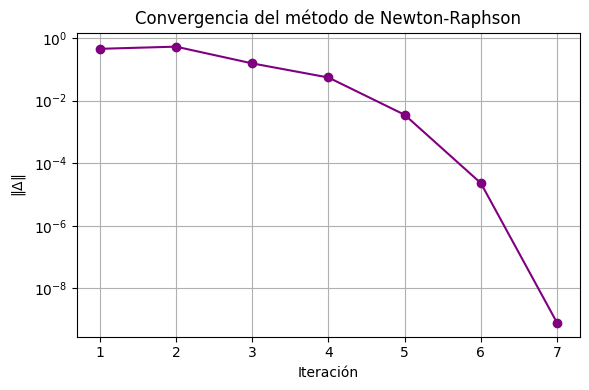

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Definimos la función F: sistema no lineal
def F(x):
    return np.array([
        np.sin(x[0]) + x[1]**2 - 1,
        x[0]**2 + x[1] -1
    ])

# Jacobiana del sistema
def J(x):
    return np.array([
        [np.cos(x[0]), 2*x[1]],
        [2*x[0],     1]
    ])

# Método de Newton-Raphson multivariable con registro de errores
def newton_multivariable(F, J, x0, tol=1e-6, max_iter=20):
    x = x0
    deltas = []  # Guardamos la norma del paso
    for i in range(max_iter):
        Fx = F(x)
        Jx = J(x)
        delta = np.linalg.solve(Jx, -Fx)
        x = x + delta
        norma_delta = np.linalg.norm(delta)
        deltas.append(norma_delta)
        print(f"Iteración {i+1}: x = {x}, ||delta|| = {norma_delta}")
        if norma_delta < tol:
            break
    return x, deltas

# Punto inicial
x0 = np.array([0.5, 0.5])

# Ejecutamos el método
solucion, deltas = newton_multivariable(F, J, x0)
print("Solución aproximada:", solucion)
print("Iteraciones totales:", len(deltas))

# Graficamos la norma del paso por iteración
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(deltas)+1), deltas, marker='o', linestyle='-', color='purple')
plt.xlabel("Iteración")
plt.ylabel(r"$\|\Delta\|$")
plt.yscale('log')  # Escala logarítmica para ver mejor la convergencia
plt.title("Convergencia del método de Newton-Raphson")
plt.grid(True)
plt.tight_layout()
plt.show()


##### **Ejercicio 3: Sistema acoplado no lineal**

**Descripción del problema:**  
Resuelva:
$$
\left\{
  \begin{array}{l}
    e^x+y^3=5 \\
    x^2 + \cos(y) = 2.
  \end{array}
\right.
$$

**Objetivos:**  
- Implementar correctamente la función y su Jacobiana.
- Usar punto inicial $x^{(0)} = [1, 1]$.
- Analizar si el método converge.

##### **Ejercicio 4: Dificultad numérica**

**Descripción del problema:**  
Resuelva el sistema:
$$
\left\{
  \begin{array}{l}
    x^3 + y - 1 = 0 \\
    x + y^3 - 1 = 0.
  \end{array}
\right.
$$

**Objetivos:**  
- Implementar el método para distintas condiciones iniciales.
- Estudiar la sensibilidad a la elección de $x^{(0)}$.
- Comentar sobre existencia de múltiples soluciones.

#### **Descomposición en valores singulares (SVD)**

La **descomposición en valores singulares (SVD)** es una herramienta fundamental en álgebra lineal numérica. Permite descomponer cualquier matriz real o compleja $A \in \mathbb{R}^{m \times n}$ como el producto de tres matrices:

$$
A = U \Sigma V^T
$$

donde:

- $U \in \mathbb{R}^{m \times m}$ es una matriz ortogonal (sus columnas son vectores ortonormales, conocidos como **vectores singulares izquierdos**),
- $\Sigma \in \mathbb{R}^{m \times n}$ es una matriz diagonal (con **valores singulares** no negativos en orden decreciente),
- $V \in \mathbb{R}^{n \times n}$ es otra matriz ortogonal (sus columnas son los **vectores singulares derechos**).

SVD se utiliza ampliamente en:
- Reducción de dimensión y compresión de datos.
- Análisis de imágenes y señales.
- Detección de rangos y resolución de sistemas sobredeterminados.
- Métodos de recomendación y machine learning.


##### **Ejemplo: Implementación básica de SVD y truncamiento**

**Descripción del problema:**  
Considere la matriz:

$$
A = \begin{bmatrix}
3 & 1 & 1 \\
-1 & 3 & 1
\end{bmatrix}.
$$

Queremos:
- Calcular su descomposición SVD.
- Mostrar los vectores singulares y valores singulares.
- Reconstruir una aproximación truncada de rango 1 de la matriz original.

**Objetivos:**
- Utilizar `numpy.linalg.svd`.
- Analizar cómo se puede truncar la matriz para obtener una aproximación de menor rango.
- Visualizar la reconstrucción y el error de aproximación.


In [ ]:
import numpy as np

# Definimos la matriz A
A = np.array([[3, 1, 1],
              [-1, 3, 1]])

# Calculamos la descomposición SVD
U, S, VT = np.linalg.svd(A)

print("Matriz U (vectores singulares izquierdos):")
print(U)

print("\nValores singulares:")
print(S)

print("\nMatriz V^T (transpuesta de los vectores singulares derechos):")
print(VT)

# Reconstruimos la matriz original usando SVD completa
Sigma_full = np.zeros_like(A, dtype=float)
np.fill_diagonal(Sigma_full, S)
A_reconstruida = U @ Sigma_full @ VT

print("\nReconstrucción completa de A:")
print(A_reconstruida)

# Reconstrucción truncada de rango 1
Sigma_r1 = np.zeros_like(A, dtype=float)
Sigma_r1[0, 0] = S[0]
A_truncada = U @ Sigma_r1 @ VT

print("\nReconstrucción truncada de rango 1:")
print(A_truncada)

# Cálculo del error de aproximación
error = np.linalg.norm(A - A_truncada)
print("\nNorma del error de truncamiento:", error)

Matriz U (vectores singulares izquierdos):
[[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]

Valores singulares:
[3.46410162 3.16227766]

Matriz V^T (transpuesta de los vectores singulares derechos):
[[-4.08248290e-01 -8.16496581e-01 -4.08248290e-01]
 [-8.94427191e-01  4.47213595e-01  5.26260748e-16]
 [-1.82574186e-01 -3.65148372e-01  9.12870929e-01]]

Reconstrucción completa de A:
[[ 3.  1.  1.]
 [-1.  3.  1.]]

Reconstrucción truncada de rango 1:
[[1. 2. 1.]
 [1. 2. 1.]]

Norma del error de truncamiento: 3.1622776601683795


##### **Ejercicio 1: Primeros pasos con SVD**

**Descripción del problema:**  
Considere la matriz:
$$
A = \begin{bmatrix}
4 & 0 \\
3 & -5
\end{bmatrix}.
$$

**Objetivos:**  
- Calcular su descomposición SVD.
- Imprimir las matrices $U$, $\Sigma$ y $V^T$.
- Verificar que $A=U\Sigma V^T$.



##### **Ejercicio 2: Aproximación truncada de una imagen**

**Descripción del problema:**  
Utilice una matriz $A\in \mathbb{R}^{5\times 5}$ definida manualmente. Por ejemplo, una matriz con un patrón visual simple.

**Objetivos:**  
- Calcular la SVD.
- Realizar una reconstrucción de rango 1 y rango 2.
- Mostrar los errores relativos de cada aproximación.

##### **Ejercicio 3: Compresión de datos**

**Descripción del problema:**  
Cree una matriz aleatoria $A\in \mathbb{R}^{10\times 10}$ con `numpy.random.rand`.

**Objetivos:**  
- Calcular la SVD.
- Comparar la reconstrucción original con truncamientos de rango $r=1, 3, 5$.
- Graficar el error de reconstrucción en función de $r$.

##### **Ejercicio 4: Aplicación a recomendación**


**Descripción del problema:**  
Considere una matriz $A\in \mathbb{R}^{6\times 5}$ representando preferencias de usuarios sobre productos (valores entre 0 y 5). Complete manualmente con algunos ceros representando datos faltantes.

**Objetivos:**  
- Calcular la SVD.
- Realizar una aproximación de bajo rango (rango 2).
- Usar la reconstrucción para predecir los valores faltantes.